In [1]:
##%%
# =======================Generate state preparation quantum circuit===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
from qiskit import QuantumCircuit, transpile
# conda qiskit
from qiskit_aer import AerSimulator
# conda cpflow
# from qiskit.providers.aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.quantum_info import Operator
from numpy import pi, exp, sqrt, abs, real, imag
from scipy import linalg

In [2]:
def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

from qiskit.quantum_info import Operator

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny
    circ = QuantumCircuit(q_num)

    circ.initialize(initial_state) 
    circ.barrier()

    from qiskit.circuit.library import QFT
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()

    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))

    # H = np.diag(np.fft.fftfreq(N)*N)
    # U = linalg.expm(-1j*H**2*dt/2)
    # circ.append(Operator(U), range(nx))
    # circ.append(Operator(U), range(nx, nx+ny))
    circ.barrier()

    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))

    circ.draw('mpl')

    circ.save_state()
    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)

    result = simulator.run(circ).result()
    result.data(0)
    tmp = np.zeros(2**q_num, dtype='complex128')
    for i in range(2**q_num):
        tmp[i] = result.data(0)['statevector'][i]
    return tmp

In [3]:
# %%
# =========================Output the wave function==========================
def compute_fluid_quantities(psi1):
    kx = np.fft.fftfreq(N)*N
    ky = np.fft.fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j*KX*psi1_spec)
    dpsi1_y = np.fft.ifft2(1j*KY*psi1_spec)
    
    rho = np.abs(psi1)**2 
    ux = np.real(np.real(psi1)*np.imag(dpsi1_x) - np.imag(psi1)*np.real(dpsi1_x)) / rho
    uy = np.real(np.real(psi1)*np.imag(dpsi1_y) - np.imag(psi1)*np.real(dpsi1_y)) / rho
    return rho, ux, uy

N = 2**5
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
dx = 2*pi/N
dy = 2*pi/N
X, Y = np.meshgrid(x, y)

# 原代码 (涡核在中心)
# R = sqrt(X**2 + Y**2)  # 默认以(0,0)为中心

# 调整为 (x0,y0) 处的涡核
x0 = 0  # 涡核中心x坐标
y0 = 0 # 涡核中心y坐标
R = sqrt((X - x0)**2 + (Y - y0)**2)  # 相对涡核中心的距离

# sigma = 1
# f = exp(-(R/sigma)**4)
# u = 2*(X + 1j*Y)*f / (1 + R**2)
# v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
# psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
# psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)

psi0 =  exp(-Y**2 + 1j*X)

initial_state = psi0.reshape(-1)
magnitude = np.linalg.norm(initial_state)
initial_state = initial_state/magnitude

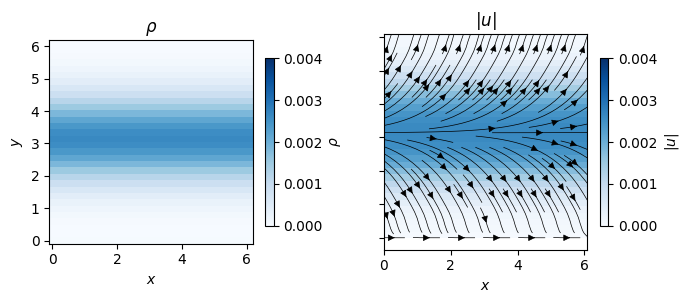

In [6]:
# %%
# =========================Run the circuit==========================
import math
nx = int(math.log2(N))
ny = int(math.log2(N))
dt = math.pi / 4 # time step
#dt = 0.75
# dt = 2
tmp = evolve(nx, ny, dt, initial_state)

tmp = tmp.reshape(N, N)

psi = tmp

rho, ux, uy = compute_fluid_quantities(psi)


import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = np.linspace(0, 2*np.pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# 单个正方形宽高
side_cm = 8
fig_width = (side_cm*2 + 1) / 2.54    # 两个正方形加一点间隔
fig_height = side_cm / 2.54

fig = plt.figure(figsize=(fig_width, fig_height))

# 左图
ax1 = fig.add_axes([0.04, 0.12, 0.38, 0.76])   # [left, bottom, width, height]
pcm = ax1.pcolormesh(
    X, Y, rho,
    cmap='Blues',
    vmin=0, vmax=0.004
)
ax1.set_aspect('equal')
ax1.set_title(r"$\rho$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")
cb1 = fig.colorbar(pcm, ax=ax1, shrink=0.7, label=r'$\rho$')

# 右图（和左图一样大，只是位置右移）

Jx = ux * rho
Jy = uy * rho
J_abs = np.sqrt(Jx**2 + Jy**2)

ax2 = fig.add_axes([0.54, 0.12, 0.38, 0.76])
im = ax2.imshow(
    J_abs ,   
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap='Blues',
    origin='lower',
    vmin=0,
    vmax = 0.004
)

ax2.set_aspect('equal')
strm = ax2.streamplot(
    x, y,
    ux, uy,
    density=1,
    color='k',      
    linewidth=0.5,
)
ax2.set_title(r"$|u|$")
ax2.set_xlabel(r"$x$")
ax2.set_yticklabels([])  
cb2 = fig.colorbar(im, ax=ax2, shrink=0.7, label=r'$|u|$')

plt.show()
